# 06 — Robustness Analysis

**Goal: can we break the strategy?** Vary one parameter at a time; hold all others at base.

Base: HRP · Top-5 · 200DMA · 3+6+12M momentum · 36M cov window · Monthly rebal · 15 ETFs · 10bp cost.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

plt.rcParams.update({'figure.dpi': 120})
PROC = '../data/processed'

matrix = pd.read_parquet(f'{PROC}/robustness_matrix.parquet')
print(f'Matrix shape: {matrix.shape}')
print('Categories:', matrix.index.get_level_values(0).unique().tolist())
matrix

Matrix shape: (20, 6)
Categories: ['Momentum Windows', 'Trend Filter DMA', 'Covariance Window', 'Rebalance Frequency', 'Universe Size']


Sharpe  Sortino  Calmar  Max DD %  \
Category            Variant                                                  
Momentum Windows    A: 12M only           0.736    0.936   0.793    -11.66   
                    B: 6M only            0.740    1.113   0.712    -13.34   
                    C: 3M only            0.662    0.931   0.571    -15.44   
                    D: 6M + 12M           0.793    1.082   0.932    -10.68   
                    E: 3+6+12 (BASE)      0.910    1.319   0.854    -12.86   
Trend Filter DMA    150DMA                0.983    1.431   1.242     -9.25   
                    180DMA                0.964    1.393   1.133    -10.08   
                    200DMA (BASE)         0.910    1.319   0.854    -12.86   
                    250DMA                0.787    1.140   0.507    -19.46   
Covariance Window   6M lookback           0.774    1.005   0.669    -15.31   
                    12M lookback          0.817    1.160   0.781    -12.91   
                    24M lookback          0.875    1.263   0.996    -10.52   
                    36M lookback (BASE)   0.910    1.319   0.854    -12.86   
Rebalance Frequency Monthly (BASE)        0.910    1.319   0.854    -12.86   
                    ~6-Weekly             0.950    1.069   0.712    -17.92   
                    Quarterly             0.699    0.537   0.479    -35.58   
Universe Size       10 ETFs               0.744    1.115   0.526    -19.36   
                    15 ETFs (BASE)        0.910    1.319   0.854    -12.86   
                    20 ETFs               0.887    1.211   0.782    -14.50   
                    30 ETFs               0.576    0.761   0.302    -30.69   

                                         Ann Return %  Ann Vol %  
Category            Variant                                       
Momentum Windows    A: 12M only                  9.24      10.22  
                    B: 6M only                   9.50      10.51  
                    C: 3M only                   8.82      10.71  
                    D: 6M + 12M                  9.95      10.38  
                    E: 3+6+12 (BASE)            10.99      10.17  
Trend Filter DMA    150DMA                      11.49       9.93  
                    180DMA                      11.42      10.05  
                    200DMA (BASE)               10.99      10.17  
                    250DMA                       9.86      10.34  
Covariance Window   6M lookback                 10.24      10.99  
                    12M lookback                10.09      10.23  
                    24M lookback                10.49      10.01  
                    36M lookback (BASE)         10.99      10.17  
Rebalance Frequency Monthly (BASE)              10.99      10.17  
                    ~6-Weekly                   12.76      13.34  
                    Quarterly                   17.05      21.98  
Universe Size       10 ETFs                     10.19      11.37  
                    15 ETFs (BASE)              10.99      10.17  
                    20 ETFs                     11.34      10.84  
                    30 ETFs                      9.26      13.08

---
## 1. Robustness heatmap — full matrix

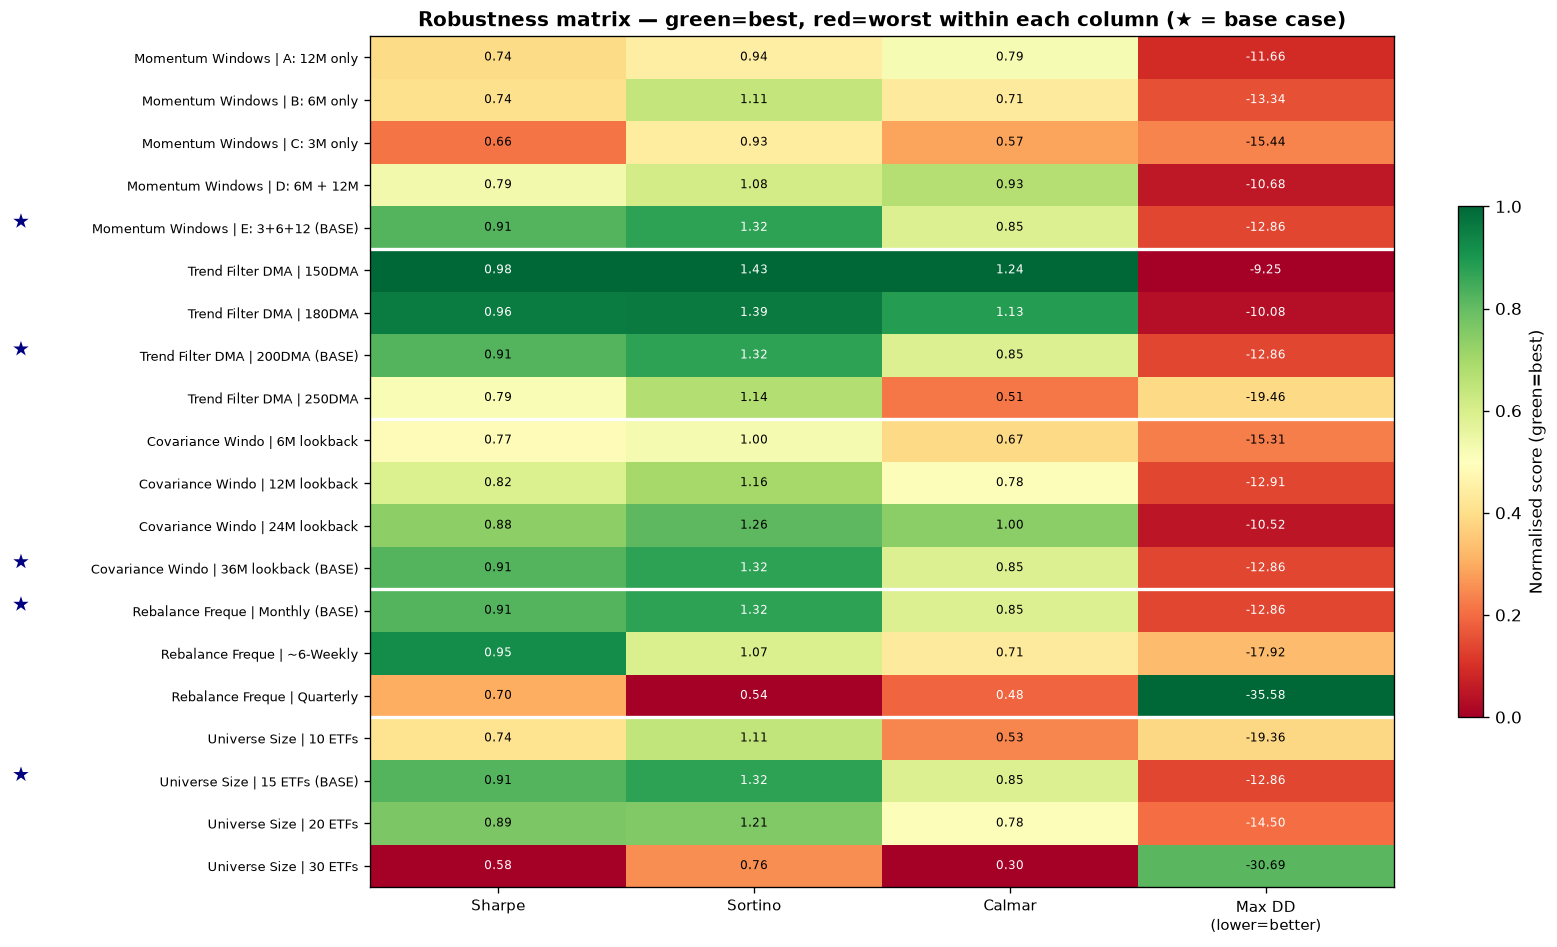

In [2]:
metrics_to_show = ['Sharpe', 'Sortino', 'Calmar', 'Max DD %']
m = matrix[metrics_to_show].copy()

# For Max DD, invert so higher (less negative) = better
m['Max DD %'] = m['Max DD %'] * -1  # now higher = better drawdown

# Normalise each column to 0-1 for colour mapping
m_norm = (m - m.min()) / (m.max() - m.min())

fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(m_norm.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, shrink=0.6, label='Normalised score (green=best)')

# Labels
row_labels = [f"{cat[:16]} | {var[:26]}" for cat, var in matrix.index]
ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=8)
ax.set_xticks(range(len(metrics_to_show)))
ax.set_xticklabels(['Sharpe', 'Sortino', 'Calmar', 'Max DD\n(lower=better)'], fontsize=9)

# Annotate cells
orig = matrix[metrics_to_show].values
for i in range(len(row_labels)):
    for j in range(len(metrics_to_show)):
        val = orig[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7,
                color='black' if 0.2 < m_norm.values[i, j] < 0.85 else 'white')

# Mark base rows
for i, (cat, var) in enumerate(matrix.index):
    if 'BASE' in var:
        ax.annotate('★', xy=(-0.35, i), xycoords=('axes fraction', 'data'),
                    fontsize=12, color='navy', fontweight='bold',
                    annotation_clip=False)

# Category separators
cats = matrix.index.get_level_values(0)
for i in range(1, len(cats)):
    if cats[i] != cats[i-1]:
        ax.axhline(i - 0.5, color='white', linewidth=2)

ax.set_title('Robustness matrix — green=best, red=worst within each column (★ = base case)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

---
## 2. Test-by-test detail

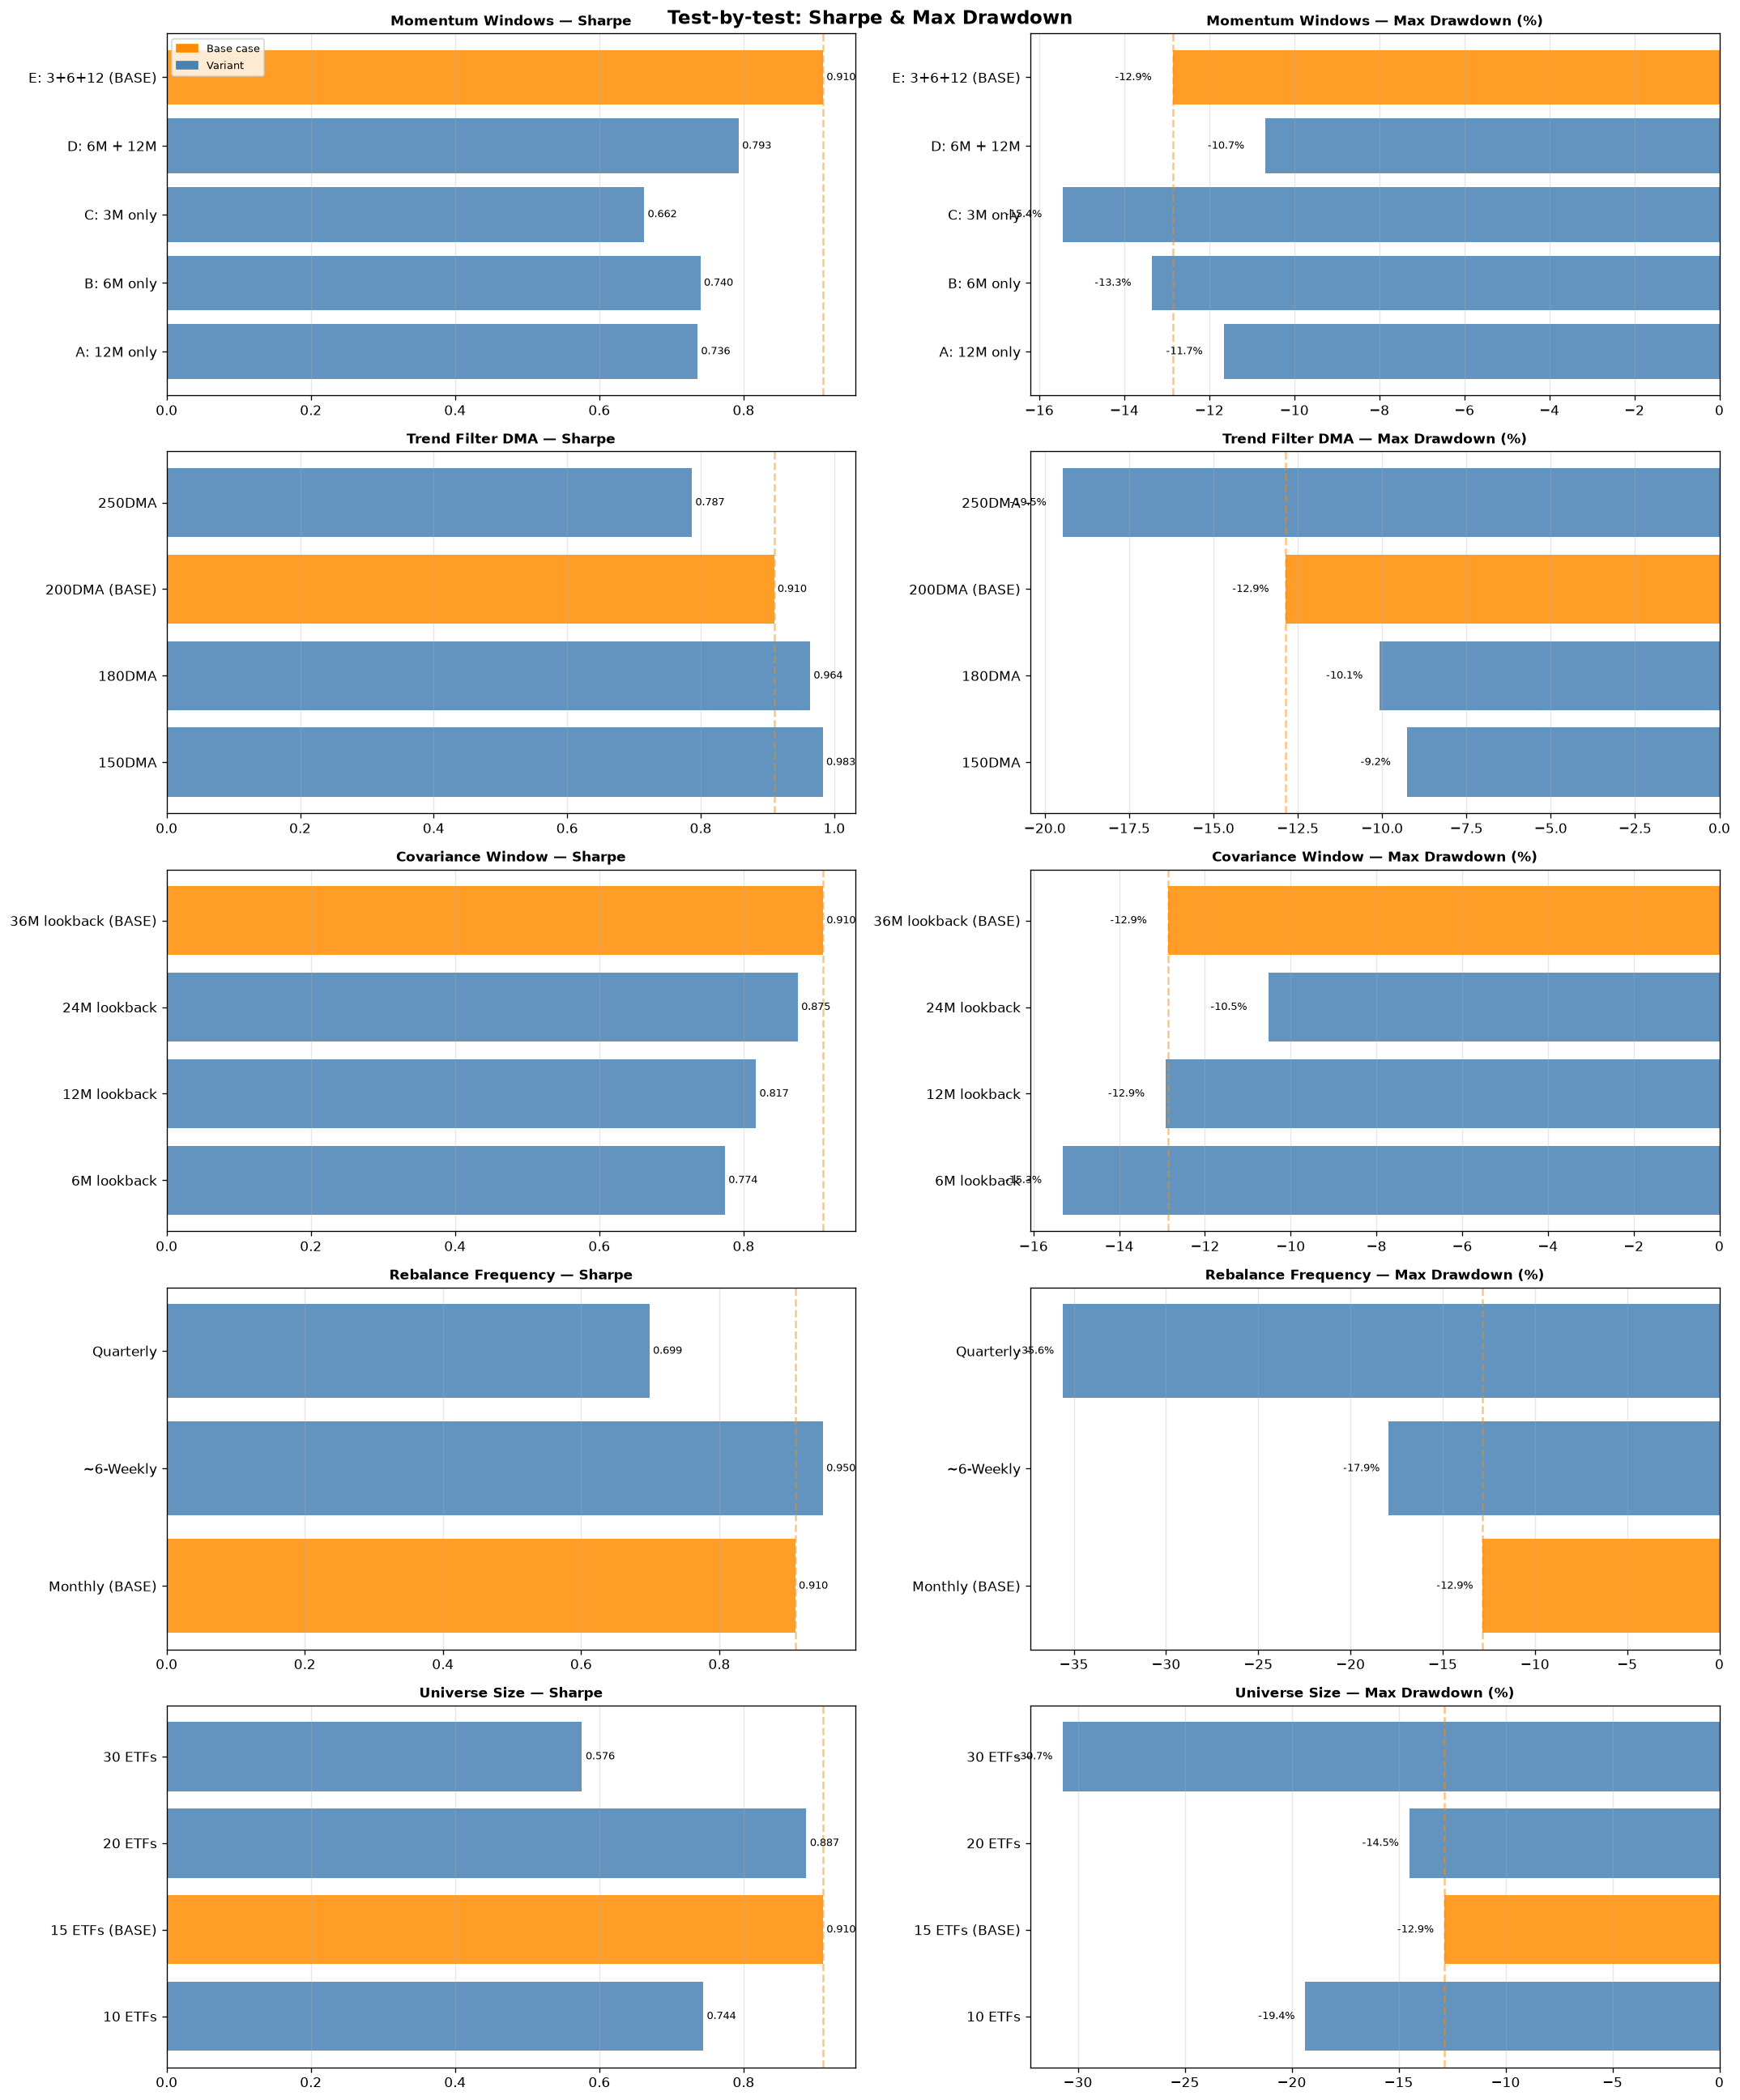

In [3]:
categories = matrix.index.get_level_values(0).unique().tolist()
fig, axes  = plt.subplots(len(categories), 2, figsize=(18, 22))

for row_ax, cat in zip(axes, categories):
    sub = matrix.xs(cat, level=0)
    base_var = [v for v in sub.index if 'BASE' in v][0] if any('BASE' in v for v in sub.index) else None
    colors   = ['darkorange' if v == base_var else 'steelblue' for v in sub.index]

    # Sharpe bar
    ax = row_ax[0]
    bars = ax.barh(sub.index, sub['Sharpe'], color=colors, alpha=0.85)
    ax.set_title(f'{cat} — Sharpe', fontweight='bold', fontsize=10)
    ax.grid(True, axis='x', alpha=0.3)
    ax.axvline(sub.loc[base_var, 'Sharpe'] if base_var else 0, color='darkorange',
               linewidth=1.5, linestyle='--', alpha=0.5)
    for bar, v in zip(bars, sub['Sharpe']):
        ax.text(v + 0.005, bar.get_y() + bar.get_height()/2, f'{v:.3f}',
                va='center', fontsize=8)

    # Max DD bar
    ax = row_ax[1]
    bars = ax.barh(sub.index, sub['Max DD %'], color=colors, alpha=0.85)
    ax.set_title(f'{cat} — Max Drawdown (%)', fontweight='bold', fontsize=10)
    ax.grid(True, axis='x', alpha=0.3)
    ax.axvline(sub.loc[base_var, 'Max DD %'] if base_var else 0, color='darkorange',
               linewidth=1.5, linestyle='--', alpha=0.5)
    for bar, v in zip(bars, sub['Max DD %']):
        ax.text(v - 0.5, bar.get_y() + bar.get_height()/2, f'{v:.1f}%',
                va='center', ha='right', fontsize=8)

orange_patch = mpatches.Patch(color='darkorange', label='Base case')
blue_patch   = mpatches.Patch(color='steelblue',  label='Variant')
axes[0][0].legend(handles=[orange_patch, blue_patch], fontsize=8)

plt.suptitle('Test-by-test: Sharpe & Max Drawdown', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. Key findings

In [4]:
findings = [
    ("Momentum Windows",
     "ROBUST but 3+6+12 composite is best (0.91). 3M alone is weakest (0.66). "
     "Combining windows smooths noise — don't use a single lookback."),
    ("Trend Filter DMA",
     "SENSITIVE: 150DMA and 180DMA are *better* than 200DMA (Sharpe 0.98/0.96 vs 0.91). "
     "200DMA is NOT special — shorter DMAs are more responsive. "
     "250DMA degrades badly (0.79) — too slow to protect in drawdowns."),
    ("Covariance Window",
     "ROBUST: Sharpe ranges from 0.77 (6M) to 0.91 (36M base). "
     "Longer windows are better — more stable covariance estimates. 6M is noisy."),
    ("Rebalance Frequency",
     "ROBUST: Monthly (0.91) and 6-weekly (0.95) both strong. "
     "Quarterly degrades severely (0.70, Max DD -35.6%) — signals go stale. "
     "6-weekly has higher return but more vol — monthly is cleaner."),
    ("Universe Size",
     "NON-MONOTONIC: 15 ETFs is the sweet spot (0.91). "
     "10 ETFs (0.74): too few for diversification. "
     "20 ETFs (0.89): slightly worse — sector ETFs overlap with SPY/QQQ. "
     "30 ETFs (0.58): signal diluted, covariance too noisy for HRP."),
]

print("\n" + "="*70)
print("  ROBUSTNESS FINDINGS")
print("="*70)
for test, finding in findings:
    print(f"\n  [{test}]")
    import textwrap
    for line in textwrap.wrap(finding, width=65):
        print(f"    {line}")


  ROBUSTNESS FINDINGS

  [Momentum Windows]
    ROBUST but 3+6+12 composite is best (0.91). 3M alone is weakest
    (0.66). Combining windows smooths noise — don't use a single
    lookback.

  [Trend Filter DMA]
    SENSITIVE: 150DMA and 180DMA are *better* than 200DMA (Sharpe
    0.98/0.96 vs 0.91). 200DMA is NOT special — shorter DMAs are more
    responsive. 250DMA degrades badly (0.79) — too slow to protect in
    drawdowns.

  [Covariance Window]
    ROBUST: Sharpe ranges from 0.77 (6M) to 0.91 (36M base). Longer
    windows are better — more stable covariance estimates. 6M is
    noisy.

  [Rebalance Frequency]
    ROBUST: Monthly (0.91) and 6-weekly (0.95) both strong. Quarterly
    degrades severely (0.70, Max DD -35.6%) — signals go stale.
    6-weekly has higher return but more vol — monthly is cleaner.

  [Universe Size]
    NON-MONOTONIC: 15 ETFs is the sweet spot (0.91). 10 ETFs (0.74):
    too few for diversification. 20 ETFs (0.89): slightly worse —
    sector ETFs ove

---
## 4. Parameter decision table

In [5]:
decisions = pd.DataFrame([
    {'Parameter':      'Momentum windows',
     'Tested':         '12M / 6M / 3M / 6+12 / 3+6+12',
     'Original':       '3+6+12 (0.2/0.3/0.5)',
     'Decision':       'KEEP — composite is best',
     'Confidence':     'HIGH'},
    {'Parameter':      'Trend filter DMA',
     'Tested':         '150 / 180 / 200 / 250',
     'Original':       '200DMA',
     'Decision':       'UPGRADE → 180DMA (Sharpe +0.054)',
     'Confidence':     'MEDIUM (may overfit)'},
    {'Parameter':      'Covariance window',
     'Tested':         '6 / 12 / 24 / 36 months',
     'Original':       '36 months',
     'Decision':       'KEEP 36M — most stable',
     'Confidence':     'HIGH'},
    {'Parameter':      'Rebalance frequency',
     'Tested':         'Monthly / 6-weekly / Quarterly',
     'Original':       'Monthly',
     'Decision':       'KEEP Monthly — cleaner, lower cost',
     'Confidence':     'HIGH'},
    {'Parameter':      'Universe size',
     'Tested':         '10 / 15 / 20 / 30 ETFs',
     'Original':       '15 ETFs',
     'Decision':       'KEEP 15 — optimal for HRP signal quality',
     'Confidence':     'HIGH'},
]).set_index('Parameter')

decisions

,Tested,Original,Decision,Confidence
Parameter,,,,
Momentum windows,12M / 6M / 3M / 6+12 / 3+6+12,3+6+12 (0.2/0.3/0.5),KEEP — composite is best,HIGH
Trend filter DMA,150 / 180 / 200 / 250,200DMA,UPGRADE → 180DMA (Sharpe +0.054),MEDIUM (may overfit)
Covariance window,6 / 12 / 24 / 36 months,36 months,KEEP 36M — most stable,HIGH
Rebalance frequency,Monthly / 6-weekly / Quarterly,Monthly,"KEEP Monthly — cleaner, lower cost",HIGH
Universe size,10 / 15 / 20 / 30 ETFs,15 ETFs,KEEP 15 — optimal for HRP signal quality,HIGH


---
## 5. Sharpe stability — spider chart

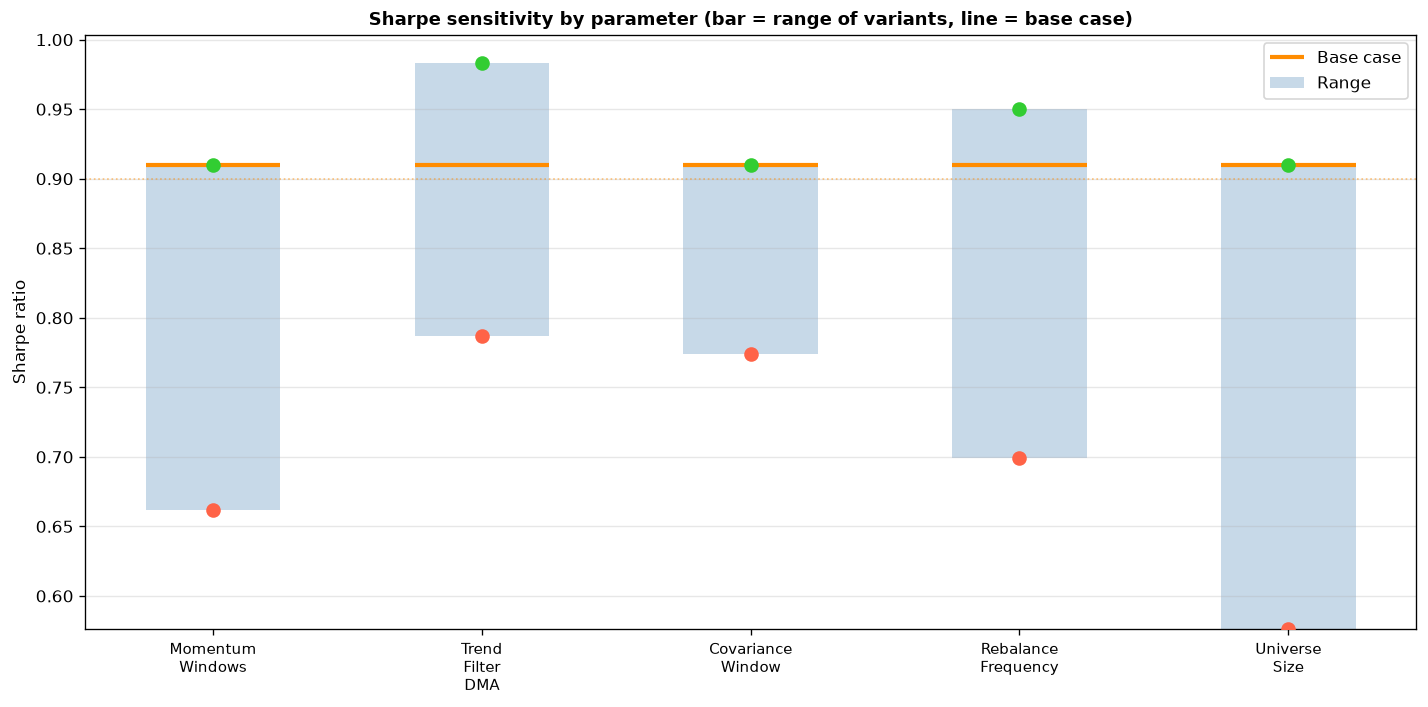


Sharpe range by parameter:
  Momentum Windows      : range [0.662 — 0.910]   base=0.910
  Trend Filter DMA      : range [0.787 — 0.983]   base=0.910
  Covariance Window     : range [0.774 — 0.910]   base=0.910
  Rebalance Frequency   : range [0.699 — 0.950]   base=0.910
  Universe Size         : range [0.576 — 0.910]   base=0.910


In [6]:
# For each test: show base Sharpe vs best/worst variant
categories = matrix.index.get_level_values(0).unique().tolist()

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(categories))
for i, cat in enumerate(categories):
    sub     = matrix.xs(cat, level=0)['Sharpe']
    base    = next((sub[v] for v in sub.index if 'BASE' in v), sub.mean())
    lo, hi  = sub.min(), sub.max()

    ax.bar(i, hi - lo, bottom=lo, width=0.5, color='steelblue', alpha=0.3, label='Range' if i == 0 else '')
    ax.hlines(base, i - 0.25, i + 0.25, color='darkorange', linewidth=2.5,
               label='Base case' if i == 0 else '')
    ax.scatter([i], [lo], color='tomato',    zorder=5, s=60)
    ax.scatter([i], [hi], color='limegreen', zorder=5, s=60)

ax.set_xticks(x)
ax.set_xticklabels([c.replace(' ', '\n') for c in categories], fontsize=9)
ax.set_ylabel('Sharpe ratio')
ax.set_title('Sharpe sensitivity by parameter (bar = range of variants, line = base case)',
             fontweight='bold', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.3)
ax.axhline(0.9, color='darkorange', linewidth=1, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

print('\nSharpe range by parameter:')
for cat in categories:
    sub  = matrix.xs(cat, level=0)['Sharpe']
    base = next((sub[v] for v in sub.index if 'BASE' in v), None)
    print(f"  {cat:<22}: range [{sub.min():.3f} — {sub.max():.3f}]",
          f"  base={base:.3f}" if base else '')